<a href="https://colab.research.google.com/github/AndrezzaLz/Basic-GUI-with-Threads/blob/main/Marketing_Campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parte 1: Análise Exploratória de Dados (AED)

Carregando o dataset a partir do arquivo .csv:
1. Baixar o arquivo csv em: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data
2. Criar um DataFrame que será carregado com os dados do arquivo csv

- Como a leitura padrão não está separando as colunas, utilizamos o separador **sep**, pois nesse arquivo elas está sendo separado por tabulações.

Explicar o objetivo antes de baixar o kaggle

In [ ]:
# Importando um CSV do Google Drive
url = 'https://drive.google.com/file/d/1tp0t00Qp9s1re5We4ok7OjX3g3NcRyxw/view?usp=drive_link'

# Pegando o ID do arquivo a partir da URL
file_id = url.split('/')[-2]

# Criando a URL para download direto no ambiente
pogo = 'https://drive.google.com/uc?id=' + file_id

df = pd.read_csv(pogo, sep="\t")

## **head()**
- Utilizamos o head para pordemos visualizar as primeiras 5 linhas do dataset
- Podemos entedner melhor os atributos (**features**) do dataset

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# **info()**
- Identifica os tipos dos dados e valores faltantes/nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Dados estatísticos
- Média, mediana etc.

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## Parte 2: Limpeza dos Dados






*   Selecionando as colunas que serão usada em nossa análise



In [ ]:
colunas_selecionadas = [
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth",
    "Income",
    "Recency"
]
colunas_selecionadas

['NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Income',
 'Recency']

In [ ]:
df = df[colunas_selecionadas]
df

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Income,Recency
0,3,8,10,4,7,58138.0,58
1,2,1,1,2,5,46344.0,38
2,1,8,2,10,4,71613.0,26
3,2,2,0,4,6,26646.0,26
4,5,5,3,6,5,58293.0,94
...,...,...,...,...,...,...,...
2235,2,9,3,4,5,61223.0,46
2236,7,8,2,5,7,64014.0,56
2237,1,2,3,13,6,56981.0,91
2238,2,6,5,10,3,69245.0,8



*   Apagando dados não numéricos e nulos

In [ ]:
df.isnull().sum()

,0
NumDealsPurchases,0
NumWebPurchases,0
NumCatalogPurchases,0
NumStorePurchases,0
NumWebVisitsMonth,0
Income,24
Recency,0


In [ ]:
print("Antes do dropna:", df.shape)
df.dropna(inplace=True)
print("depois  do dropna:", df.shape)

Antes do dropna: (2240, 7)
depois  do dropna: (2216, 7)




*   Removendo linhas duplicadas



In [ ]:
total_duplicados = int(df.duplicated().sum())
print(total_duplicados)

205


In [ ]:
print("Antes do duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("depois do duplicates:", df.shape)

Antes do duplicates: (2216, 7)
depois do duplicates: (2011, 7)




*   Verificando se existe algum item negativo



In [ ]:
int_columns = df.select_dtypes(include=['int64']).columns
df = df[(df[int_columns] >= 0).all(axis=1)]

df

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Income,Recency
0,3,8,10,4,7,58138.0,58
1,2,1,1,2,5,46344.0,38
2,1,8,2,10,4,71613.0,26
3,2,2,0,4,6,26646.0,26
4,5,5,3,6,5,58293.0,94
...,...,...,...,...,...,...,...
2233,4,3,1,3,6,666666.0,23
2235,2,9,3,4,5,61223.0,46
2237,1,2,3,13,6,56981.0,91
2238,2,6,5,10,3,69245.0,8




*   Fórmula para verificar a quantidade de Outliers em cada coluna  



In [ ]:
def contar_outliers(df, coluna, fator):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    # Encontrar outliers
    outliers = df[(df[coluna] < (Q1 - fator * IQR)) | (df[coluna] > (Q3 + fator * IQR))]

    # Exibir o número de outliers para a coluna atual
    print(f'Coluna: {coluna} - Número de outliers: {outliers.shape[0]}')

In [ ]:
for i in colunas_selecionadas:
  contar_outliers(df, i, 1.25)

Coluna: NumDealsPurchases - Número de outliers: 129
Coluna: NumWebPurchases - Número de outliers: 3
Coluna: NumCatalogPurchases - Número de outliers: 64
Coluna: NumStorePurchases - Número de outliers: 0
Coluna: NumWebVisitsMonth - Número de outliers: 9
Coluna: Income - Número de outliers: 9
Coluna: Recency - Número de outliers: 0


In [ ]:
def remover_outliers_iqr(data, coluna, fator):
    # Remove os outliers de um DataFrame com base na coluna especificada
    Q1 = data[coluna].quantile(0.25)
    Q3 = data[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - fator * IQR
    limite_superior = Q3 + fator * IQR
    data_sem_outliers = data[(data[coluna] >= limite_inferior) & (data[coluna] <= limite_superior)]
    return data_sem_outliers

In [ ]:
for i in colunas_selecionadas:
  df = remover_outliers_iqr(df, i, 1.25)

## Análise de dados

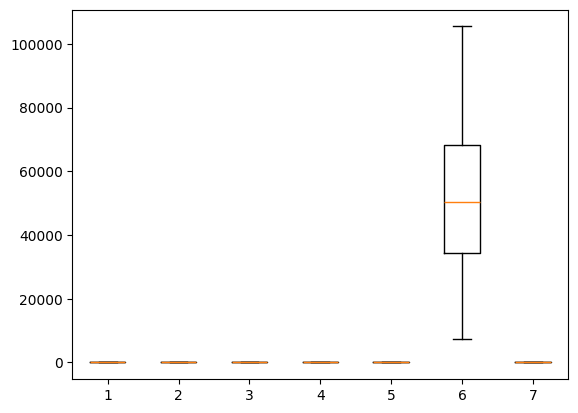

In [ ]:
plt.boxplot(df);

##Frequência de compras:


Para fazer a análise da frequencia de compras tive que importar novamente o arquivo para selecionar outras colunas que seriam interessante para nós

As colunas consideradas relevantes para nossa analise foram: NumDealsPurchases(Compras com desconto),NumWebPurchases (Compras online), NumCatalogPurchases (Compras via catálogo), NumStorePurchases (Compras na loja) e NumWebVisitsMonth (Visitas mensais no site). As colunas Income(Renda) e Recency(Recência) vão ser usadas para ver se os clientes que compram mais tem maior renda e a se os outliers são novos clientes ou antigos

Aqui é o código que está calculando a média das compras

In [ ]:
colunas_frequencia = [
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"
]

# Média das compras
media_frequencia = df[colunas_frequencia].mean()
print(media_frequencia)

NumDealsPurchases      1.991150
NumWebPurchases        3.918142
NumCatalogPurchases    2.389381
NumStorePurchases      5.723451
NumWebVisitsMonth      5.248894
dtype: float64


Com esses dados, iremos usar o KMeans para agrupar os clientes e calcular o z-score para detectar os outliers (z-score é uma métrica que indica os desvios, talvez nao se é o melhor) Um Z-score positivo indica que o valor está acima da média da distribuição, enquanto um Z-score negativo indica que o valor está abaixo da média. Quanto maior o valor absoluto do Z-score, mais incomum é o ponto de dados em relação aos demais. Por exemplo, um Z-score de 2 significa que o valor está a 2 desvios padrão acima da média.

In [ ]:
from sklearn.cluster import KMeans
from scipy.stats import zscore
import seaborn as sns

# Normalizando os dados antes da clusterização
df_cluster = df[colunas_frequencia].copy()
df_cluster = (df_cluster - df_cluster.mean()) / df_cluster.std()

# Aplicando K-Means com 3 clusters (pode ajustar conforme necessário)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df_cluster)

# Calculando o z-score para cada cliente
df["Cluster_Score"] = df_cluster.apply(zscore).sum(axis=1)

df.head()

,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Income,Recency,Cluster,Cluster_Score
1,2,1,1,2,5,46344.0,38,1,-2.944746
2,1,8,2,10,4,71613.0,26,2,1.361181
3,2,2,0,4,6,26646.0,26,1,-1.904909
4,5,5,3,6,5,58293.0,94,0,3.148494
5,2,6,4,10,6,62513.0,16,0,3.118190


In [ ]:
# Definindo outliers
contar_outliers(df, "Cluster_Score", 1.25)
df = remover_outliers_iqr(df, "Cluster_Score", 1.25)

Coluna: Cluster_Score - Número de outliers: 15


Para entender melhor os padrões de compras iremos cruzar os clusteres que fizemos com a renda (Income) e a recência (Recency).
O que isso vai nos mostrar?
- Se os clientes de alta renda estão mais ativos (compram mais vezes)
- Se clientes mais antigos têm menor frequência de compra

Criamos um gráfico de dispersão para ver se há um padrão entre a renda e o Cluster_score.
Perguntas que o gráfico pode nos responder:
 - Clientes de alta renda gastam mais e pertencem a clusters mais ativos?
 - Há clientes de baixa renda que compram muito via promoções?

In [ ]:
# Agrupando os dados por cluster e calculando médias
cluster_analysis = df.groupby("Cluster")[["Income", "Recency", "Cluster_Score"]].mean()
print(cluster_analysis)

               Income    Recency  Cluster_Score
Cluster                                        
0        56124.024752  48.891089       3.093915
1        34469.573443  49.066980      -1.968549
2        73467.724907  48.537175       0.575167


Colocar em um docs separado a função

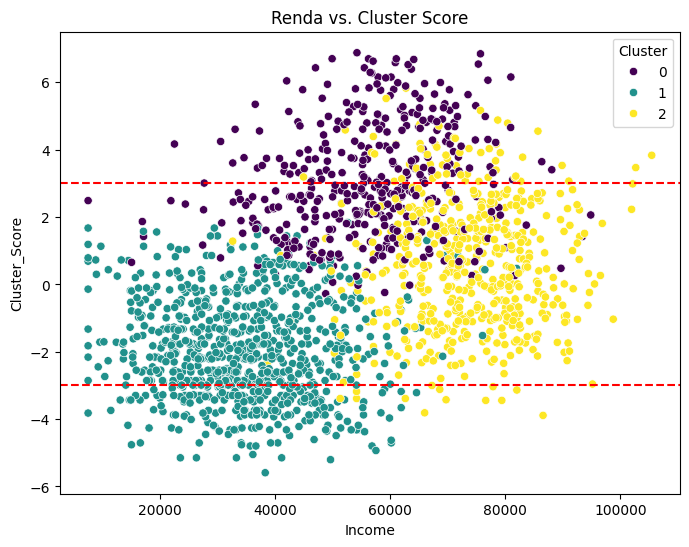

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Income", y="Cluster_Score", hue="Cluster", palette="viridis")
plt.axhline(3, color="red", linestyle="--")  # Linha indicando outliers
plt.axhline(-3, color="red", linestyle="--")
plt.title("Renda vs. Cluster Score")
plt.show()

Agora, vamos ver se clientes que compraram recentemente estão mais ativos:
O que isso mostra?

    Clientes que compraram há muito tempo (Recency alto) compram menos?
    Ou temos clientes recém-chegados já com alta frequência de compra?

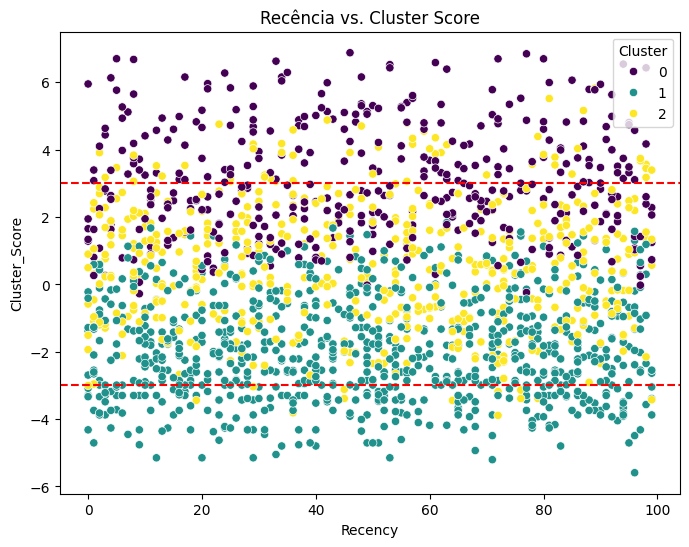

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Recency", y="Cluster_Score", hue="Cluster", palette="viridis")
plt.axhline(3, color="red", linestyle="--") # Linha indicando outliers
plt.axhline(-3, color="red", linestyle="--")
plt.title("Recência vs. Cluster Score")
plt.show()

Renda vs. Cluster Score

🔍 Observações:

    A maior parte dos clientes está concentrada em rendas menores que 100.000.
    O Cluster 2 (amarelo) tende a ter Cluster Scores mais altos, indicando maior frequência de compra.
    O Cluster 0 (roxo) tem muitos pontos com Cluster Score negativo, sugerindo baixa frequência de compra.
    Há um outlier extremo com renda acima de 600.000, pertencente ao Cluster 0, mas sem alta frequência de compra.

📌 Insights:

    Clientes de alta renda nem sempre compram com alta frequência. Estratégias para engajá-los poderiam ser exploradas.
    O Cluster 2, com clientes mais ativos, está distribuído em diferentes faixas de renda, indicando que o engajamento pode depender mais de outros fatores além da renda.

Recência vs. Cluster Score

🔍 Observações:

    O eixo Recência parece distribuído de forma homogênea entre todos os clusters.
    O Cluster 2 (vermelho) tem maior frequência de compra, independentemente da recência.
    O Cluster 0 (azul) tem baixa frequência de compra e está presente em todas as faixas de recência.
    As linhas vermelhas ajudam a identificar outliers, com alguns clientes possuindo Cluster Scores extremos.

📌 Insights:

    A recência não tem um impacto claro na frequência de compra → Clientes que compraram há pouco tempo não necessariamente compram mais.
    O Cluster 0 contém clientes com recência baixa e alta, sugerindo que ter comprado recentemente não garante engajamento.
    Foco em reativação pode ser importante para certos perfis dentro do Cluster 0.

